In [59]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [60]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=2)

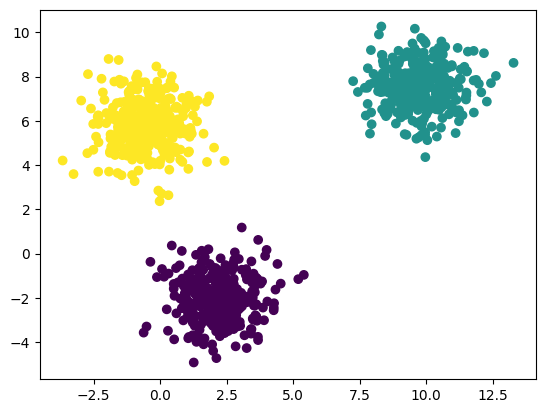

In [61]:
plt.scatter(X[:,0], X[:,1], c=y)

In [62]:
## perfform standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   # create an object of the class

In [63]:
from sklearn.model_selection import train_test_split    # split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [64]:
X_train

array([[-1.05278566,  3.55217802],
       [ 9.21596323,  6.94917852],
       [ 9.49271678,  6.00906692],
       ...,
       [ 2.32191209, -1.68266236],
       [10.43957893,  9.14024986],
       [ 1.10320261, -1.59821148]])

In [65]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
from sklearn.cluster import KMeans

In [67]:
## Elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)


In [68]:
wcss

[1600.0000000000014,
 576.5464826443344,
 82.89125934977427,
 73.63954963497444,
 63.083488255749785,
 54.552365430521036,
 49.22459264901215,
 42.71233433151275,
 40.29410273949235,
 34.622925863240226]

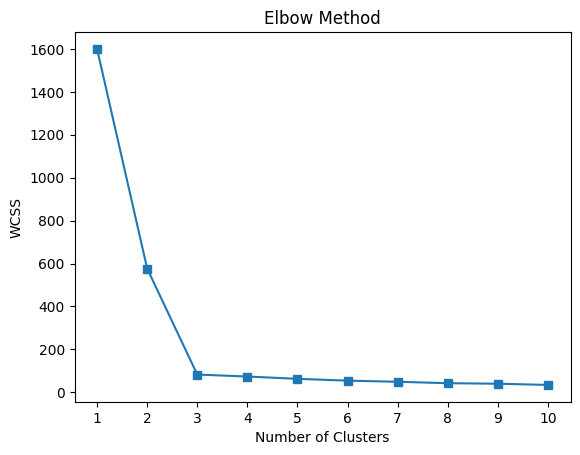

In [69]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='s')
plt.title('Elbow Method')
plt.xticks(range(1, 11))
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [70]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [71]:
kmeans.fit_predict(X_train_scaled)

array([1, 0, 0, 2, 2, 1, 2, 2, 1, 1, 0, 0, 1, 2, 0, 1, 2, 0, 2, 2, 2, 0,
       0, 2, 0, 2, 2, 1, 2, 1, 1, 2, 1, 0, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 2, 1, 1, 2, 2, 0, 0, 0, 2, 0, 2, 1, 1, 1,
       1, 2, 0, 1, 2, 0, 2, 2, 1, 2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2,
       2, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 2, 2, 1, 0, 1, 1, 2, 2, 1, 2, 1, 0, 1, 0, 0, 2, 2, 1, 0, 1,
       0, 2, 0, 2, 0, 1, 0, 0, 2, 0, 2, 1, 2, 0, 2, 2, 2, 2, 1, 2, 2, 0,
       1, 1, 2, 0, 0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 1, 2, 1, 2, 0, 0, 2, 0,
       0, 2, 2, 1, 2, 1, 0, 1, 2, 2, 2, 1, 2, 0, 1, 2, 1, 1, 2, 1, 0, 2,
       2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 0, 0, 0, 1, 0, 0, 1, 1, 2, 1, 0, 0,
       0, 0, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 2, 2, 2, 1, 2, 2, 2, 2, 0,
       1, 0, 0, 0, 2, 2, 0, 1, 0, 0, 2, 1, 0, 2, 1, 1, 2, 2, 0, 1, 1, 2,
       0, 0, 1, 2, 2, 0, 0, 1, 0, 0, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2, 2, 0,
       0, 0, 2, 0, 2, 1, 1, 0, 0, 2, 1, 0, 0, 2, 2,

In [72]:
y_pred = kmeans.predict(X_test_scaled)

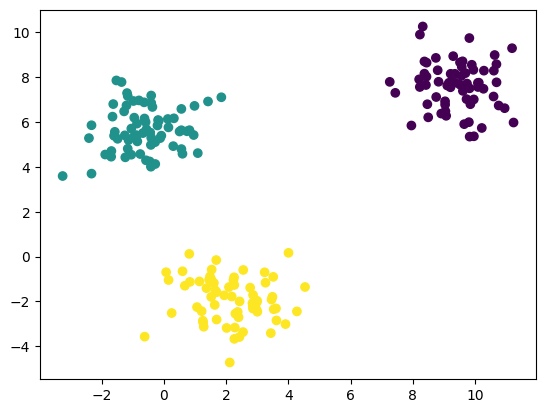

In [73]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)

## For validation of K value, There are 2 methods:

### 1. Kneelocator
### 2. Silhoutee Scoring

In [74]:
## Kneelocator
!pip install kneed

You should consider upgrading via the '/Users/pranjalparmar/Documents/ml_env/bin/python3 -m pip install --upgrade pip' command.


In [75]:
from kneed import KneeLocator

In [76]:
kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')

In [77]:
kl.elbow

np.int64(3)

In [78]:
from sklearn.metrics import silhouette_score

In [79]:
silhouette_coefficients = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [80]:
silhouette_coefficients

[np.float64(0.6419836811992201),
 np.float64(0.8018462433522805),
 np.float64(0.6325309755571655),
 np.float64(0.4691158011221559),
 np.float64(0.30616776027309345),
 np.float64(0.31882014574505135),
 np.float64(0.3332224538251477),
 np.float64(0.3310514796794788),
 np.float64(0.3393157583720122)]

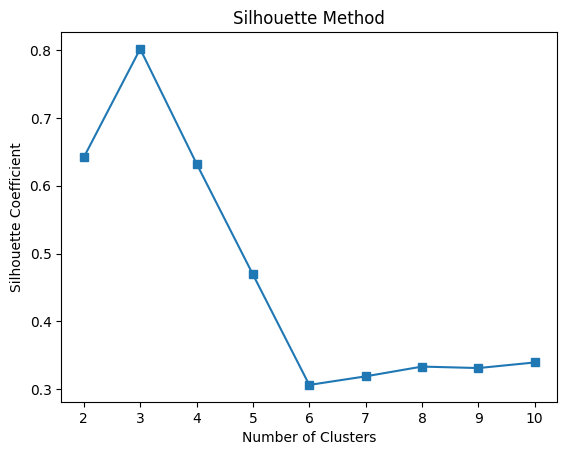

In [81]:
plt.plot(range(2, 11), silhouette_coefficients, marker='s')
plt.title('Silhouette Method')
plt.xticks(range(2, 11))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()